In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import joblib

In [6]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [7]:
rf_model = joblib.load("../models/random_forest_churn.pkl")
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [8]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

results

,Metric,Score
0,Accuracy,0.806955
1,Precision,0.677083
2,Recall,0.521390
3,F1 Score,0.589124


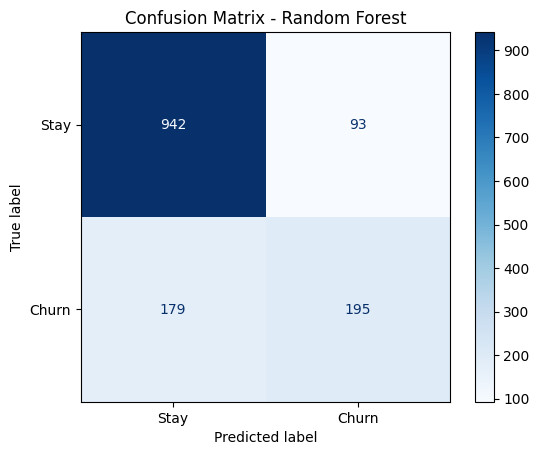

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")

plt.show()

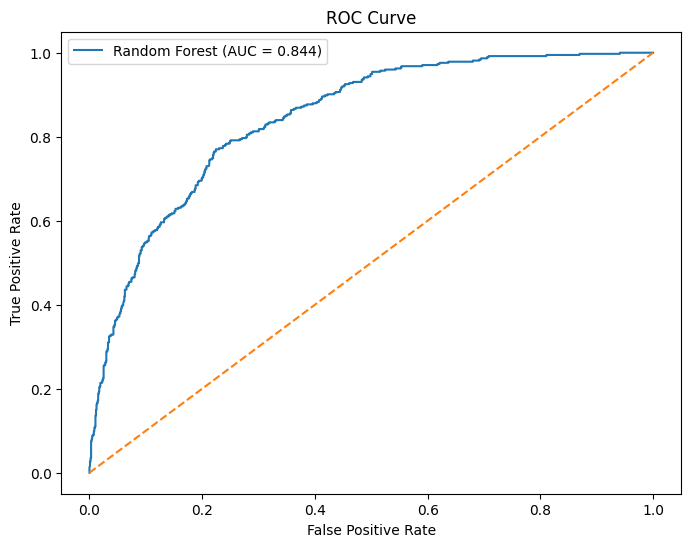

In [10]:
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"Random Forest (AUC = {auc_score:.3f})")

# Random guessing line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [11]:
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8440


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8055,
        0.7289,
        0.8070,
        0.7736
    ],
    "Precision": [
        0.66,
        0.49,
        0.68,
        0.59
    ],
    "Recall": [
        0.56,
        0.51,
        0.52,
        0.50
    ],
    "F1 Score": [
        0.60,
        0.50,
        0.59,
        0.54
    ],
    "AUC": [
        None,
        None,
        0.844,
        None
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8055,0.66,0.56,0.60,NaN
1,Decision Tree,0.7289,0.49,0.51,0.50,NaN
2,Random Forest,0.8070,0.68,0.52,0.59,0.844
3,XGBoost,0.7736,0.59,0.50,0.54,NaN


: 